In [54]:
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd
import yaml

from src.tools.presets import get_list_of_presets
from src.tools.read.generation_result.load_generation_result import load_evaluation_results


load_dotenv()

EVALUATION_DIR = Path(os.getenv("EVALUATION_DIR"))
generation_result_df = load_evaluation_results(EVALUATION_DIR)

In [55]:
generation_result_df

answers_ratio
dataset_name        dataset_params_name chunking_name    chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name generator_name       generator_params_name judge_name     judge_params_name split_name               
infiniteBenchChoice default             chonkie_semantic norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           all             53.275109
                                                                                                                                                                                              gpt_20b_4096          llm_as_a_judge qwen_4b           all             56.331878
                                                                                                                                                      default_top20_op   generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           all             57.205240
                                                                                                                                                                                              gpt_20b_4096          llm_as_a_judge qwen_4b           all             60.262009
                                                                                         default_local     faiss       default_top20      reranker    default_top20      generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           all             56.331878
...                                                                                                                                                                                                                                                                        ...
literaryQA          default             sequential_hac   norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20_op   generate_fixed_token gpt_20b_4096          llm_as_a_judge qwen_4b           test            14.293263
                                                                                         default_local     faiss       default_top20      reranker    default_top20      generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           test            30.858653
                                                                                                                                                                                              gpt_20b_4096          llm_as_a_judge qwen_4b           test            37.410832
                                                                                                                                                      default_top20_op   generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           test            23.910172
                                                                                                                                                                                              gpt_20b_4096          llm_as_a_judge qwen_4b           test            29.907530

[192 rows x 1 columns]

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

selected_names = {
    "dataset_name",
    "chunking_name",
    "embed_params_name",
    "rerank_name",
    "rerank_params_name",
    "generator_params_name",
}

def plot_metric(plot_df, metric_col):
    """
    Rysuje bar plot dla zadanej kolumny metryki.
    
    Legenda budowana jest ze wszystkich poziomów indeksu należących do `selected_names`,
    łączonych jako  level1=val1|level2=val2|...
    
    Returns
    -------
    fig, ax
    """
    index_names = list(plot_df.index.names)
    legend_levels = [n for n in index_names if n in selected_names]

    # Buduj etykiety legendy
    labels = []
    for idx in plot_df.index:
        idx_tuple = idx if isinstance(idx, tuple) else (idx,)
        idx_dict = dict(zip(index_names, idx_tuple))
        parts = [f"{lvl}={idx_dict[lvl]}" for lvl in legend_levels]
        labels.append(" | ".join(parts))

    values = plot_df[metric_col].values
    x = np.arange(len(values))

    fig, ax = plt.subplots(figsize=(max(10, len(values) * 1.5), 6))

    bars = ax.bar(x, values, width=0.6)

    # Koloruj słupki i buduj wpisy legendy
    cmap = plt.get_cmap("tab20", len(values))
    handles = []
    for i, (bar, label) in enumerate(zip(bars, labels)):
        color = cmap(i)
        bar.set_color(color)
        handles.append(plt.Rectangle((0, 0), 1, 1, color=color, label=label))

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in range(len(values))], fontsize=9)
    ax.set_ylabel(metric_col, fontsize=11)
    ax.set_title(f"{metric_col} – bar plot", fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.set_ylim(0, max(values) * 1.15 if len(values) else 1)

    # Wartości nad słupkami
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8,
        )

    # Legenda na zewnątrz wykresu (po prawej)
    ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        fontsize=8,
        title="Konfiguracja",
        title_fontsize=9,
    )

    fig.tight_layout()
    plt.show()
    return fig, ax

In [47]:
generation_result_df

answers_ratio
dataset_name        dataset_params_name chunking_name    chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name generator_name       generator_params_name judge_name     judge_params_name split_name               
infiniteBenchChoice default             chonkie_semantic norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20      generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           all             53.275109
                                                                                                                                                                                              gpt_20b_4096          llm_as_a_judge qwen_4b           all             56.331878
                                                                                                                                                      default_top20_op   generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           all             57.205240
                                                                                                                                                                                              gpt_20b_4096          llm_as_a_judge qwen_4b           all             60.262009
                                                                                         default_local     faiss       default_top20      reranker    default_top20      generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           all             56.331878
...                                                                                                                                                                                                                                                                        ...
literaryQA          default             sequential_hac   norm                 FAISS      default_global    faiss       default_top20      reranker    default_top20_op   generate_fixed_token gpt_20b_4096          llm_as_a_judge qwen_4b           test            14.293263
                                                                                         default_local     faiss       default_top20      reranker    default_top20      generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           test            30.858653
                                                                                                                                                                                              gpt_20b_4096          llm_as_a_judge qwen_4b           test            37.410832
                                                                                                                                                      default_top20_op   generate_fixed_token gpt_20b_2048          llm_as_a_judge qwen_4b           test            23.910172
                                                                                                                                                                                              gpt_20b_4096          llm_as_a_judge qwen_4b           test            29.907530

[192 rows x 1 columns]

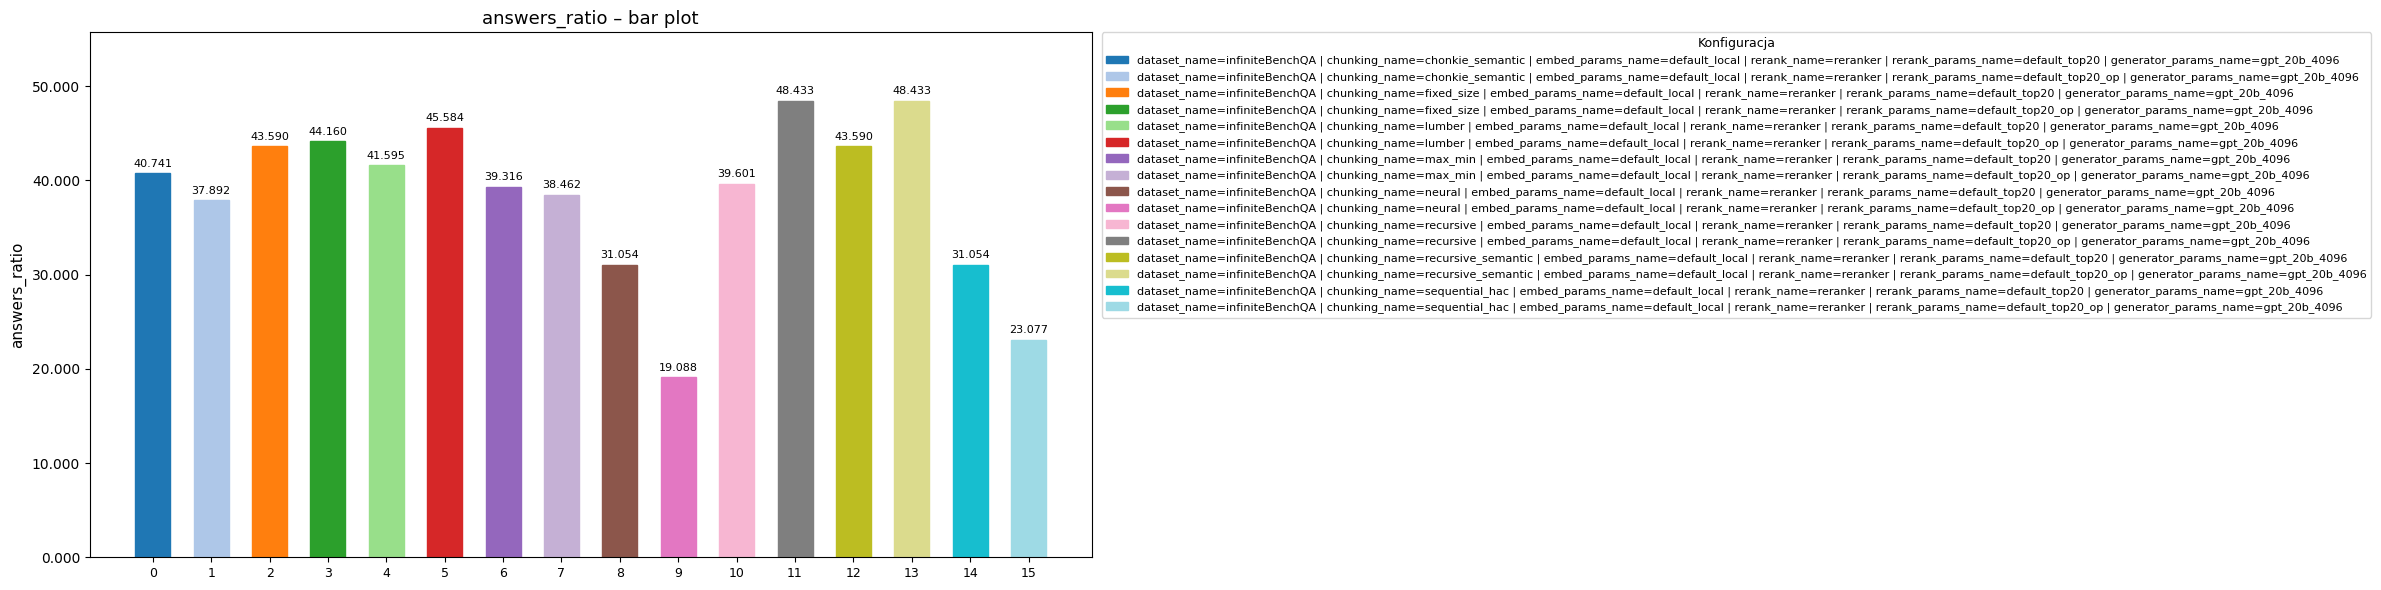

In [48]:
plot_df = generation_result_df[
    generation_result_df.index.get_level_values("dataset_name").str.contains("infiniteBenchQA", na=False)
]
plot_df = plot_df[
    plot_df.index.get_level_values("rerank_name").str.contains("reranker", na=False)
]
plot_df = plot_df[
    plot_df.index.get_level_values("embed_params_name").str.contains("local", na=False)
]
plot_df = plot_df[
    plot_df.index.get_level_values("generator_params_name").str.contains("4096", na=False)
]
metric_cols = ["answers_ratio"]
fig, axes = plot_metric(plot_df, metric_cols[0])

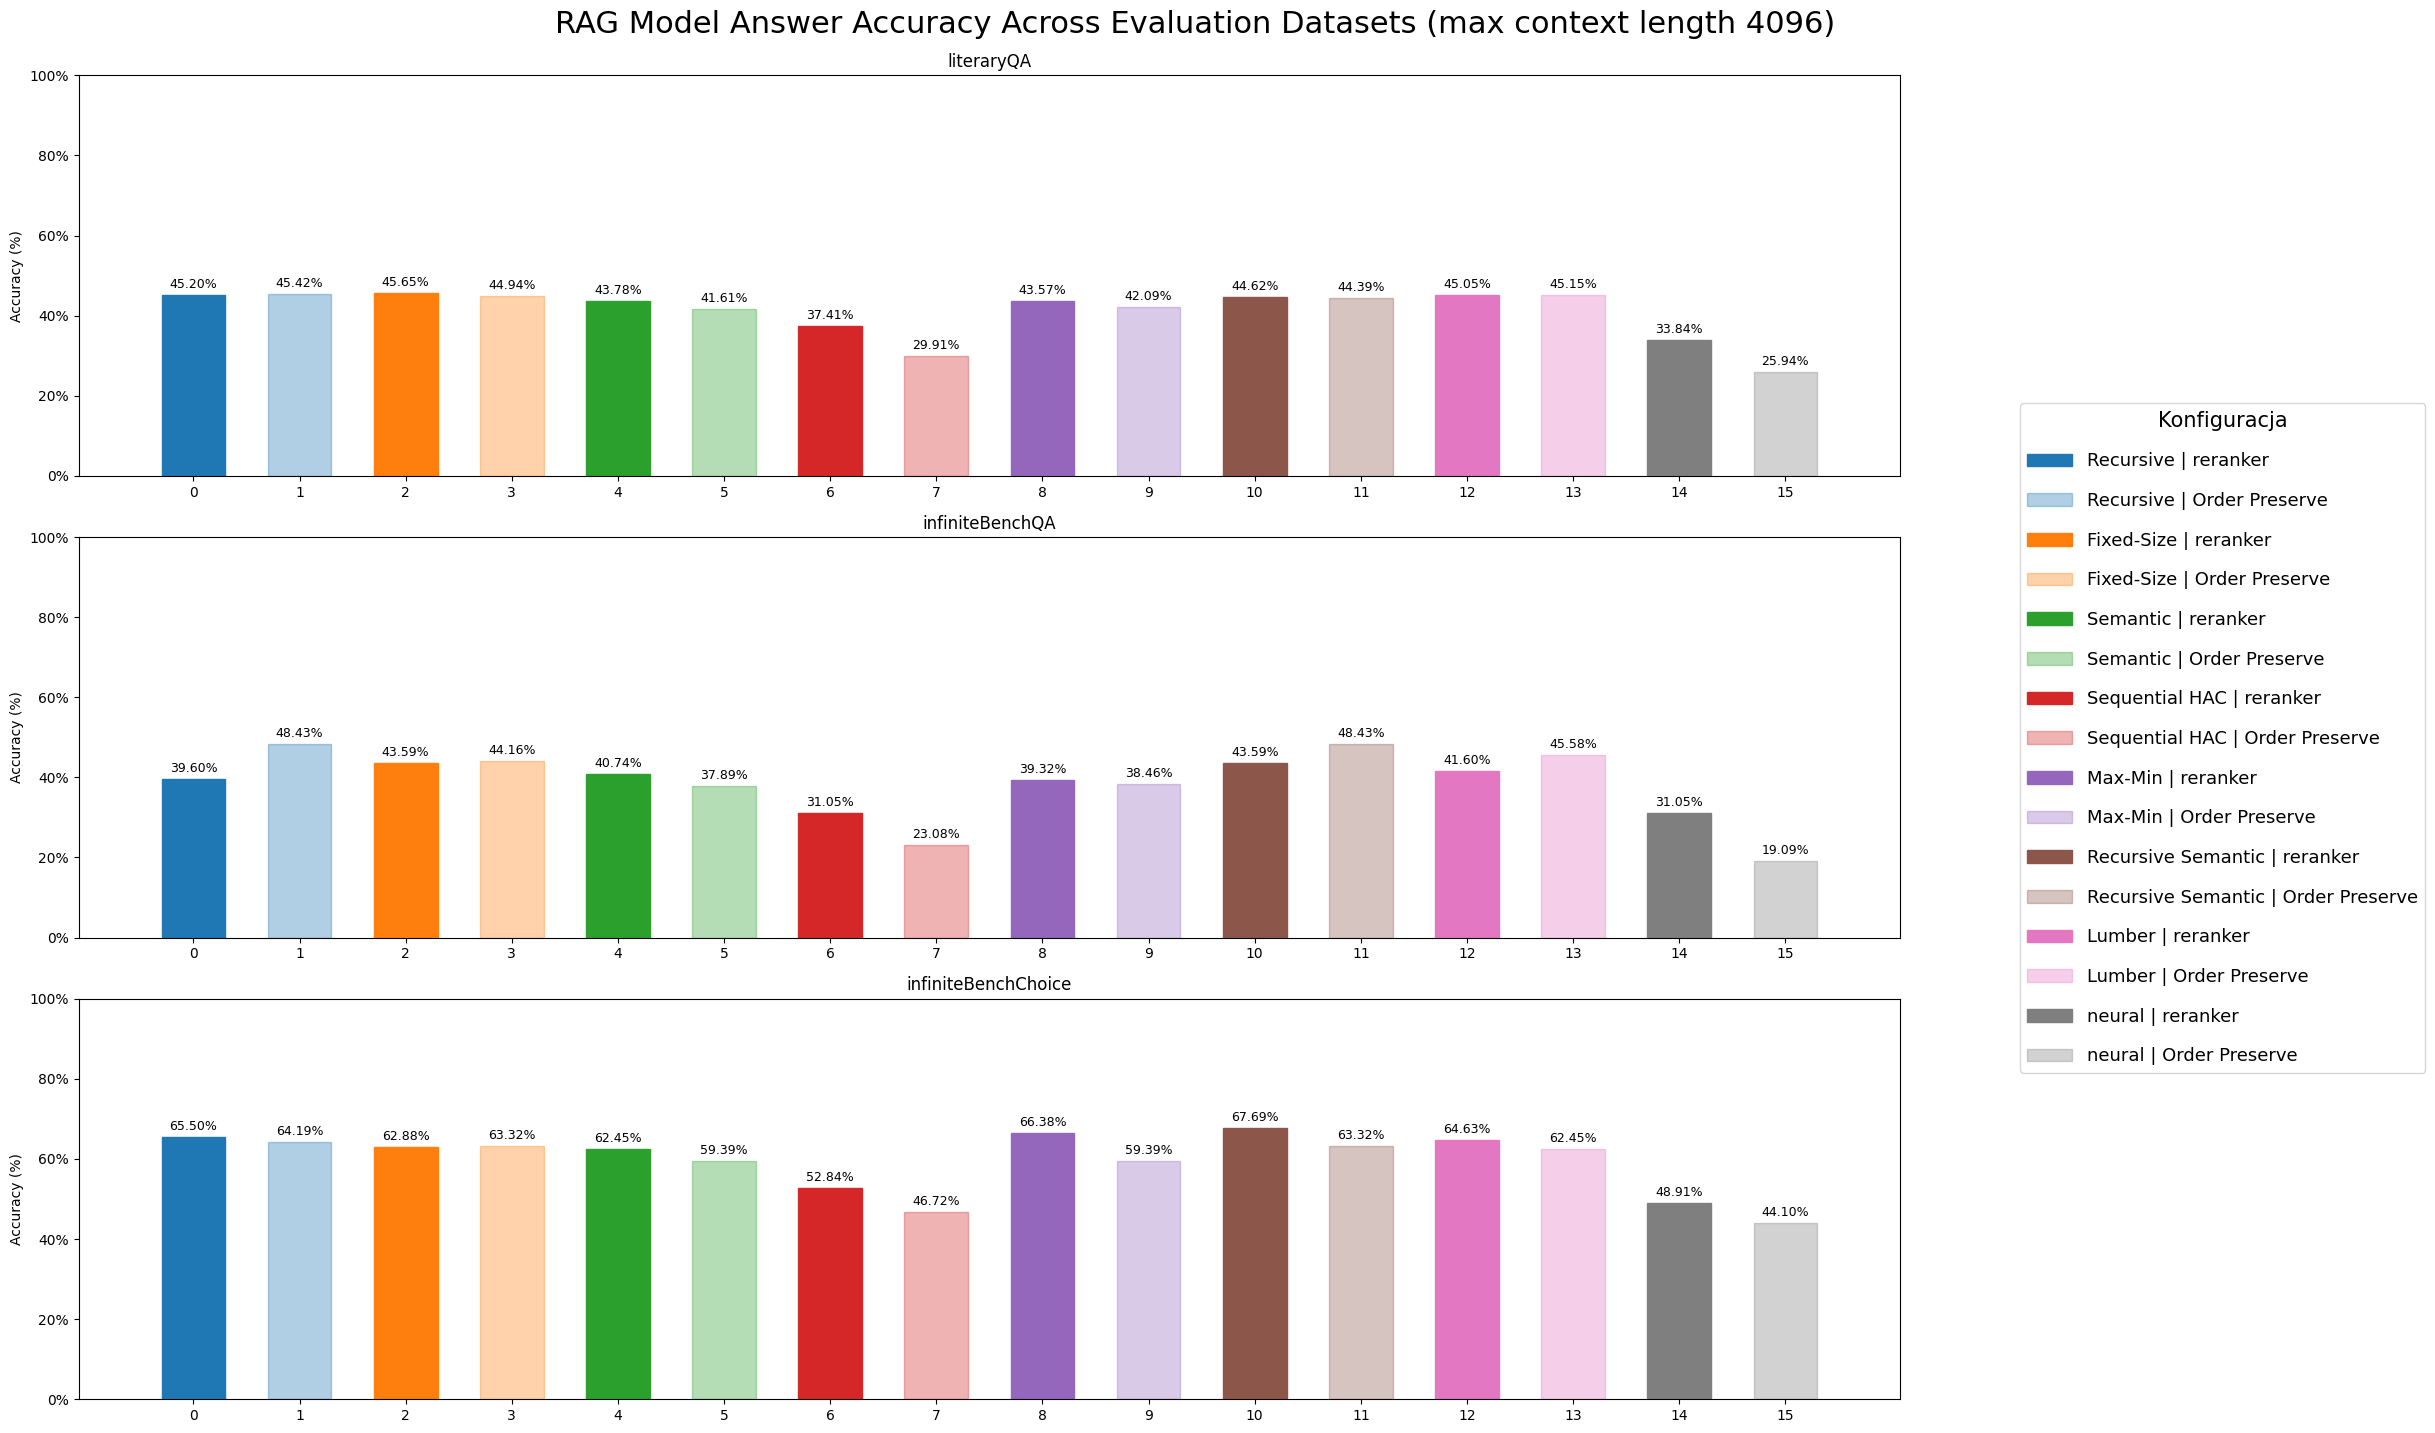

In [62]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

base_colors=["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#7f7f7f"]

dataset_names=["literaryQA","infiniteBenchQA","infiniteBenchChoice"]
metric_col="answers_ratio"

method_order=["recursive","fixed_size","chonkie_semantic","sequential_hac","max_min","neurual","recursive_semantic","lumber"]

method_names={
    "recursive":"Recursive","fixed_size":"Fixed-Size","chonkie_semantic":"Semantic",
    "sequential_hac":"Sequential HAC","max_min":"Max-Min","neurual":"Neural",
    "recursive_semantic":"Recursive Semantic","lumber":"Lumber"
}

def build_label(idx):
    m=method_names.get(str(idx[2]),str(idx[2]))
    return f"{m} | {'Order Preserve' if '_op' in str(idx[9]) else 'reranker'}"

def filter_df(df,name):
    idx=df.index
    return df[
        idx.get_level_values("dataset_name").str.contains(name,na=False) &
        idx.get_level_values("rerank_name").str.contains("reranker",na=False) &
        idx.get_level_values("embed_params_name").str.contains("local",na=False) &
        idx.get_level_values("generator_params_name").str.contains("4096",na=False)
    ]

def sort_methods(df):
    order={m:i for i,m in enumerate(method_order)}
    return df.loc[sorted(df.index,key=lambda x:order.get(str(x[2]),999))]

fig,axes=plt.subplots(len(dataset_names),1,figsize=(24,14))
axes=[axes] if len(dataset_names)==1 else axes

legend_handles,legend_labels=[],[]
first=True

for i,name in enumerate(dataset_names):
    ax=axes[i]
    plot_df=sort_methods(filter_df(generation_result_df,name))

    labels=[build_label(x if isinstance(x,tuple) else (x,)) for x in plot_df.index]
    values=plot_df[metric_col].values/100
    x=np.arange(len(values))

    bars=ax.bar(x,values,width=.6)

    for j,(bar,val,label) in enumerate(zip(bars,values,labels)):
        color=base_colors[((i*len(values)+j)//2)%len(base_colors)]
        alpha=1 if (i*len(values)+j)%2==0 else .35
        bar.set_color(color)
        bar.set_alpha(alpha)

        if first:
            legend_handles.append(plt.Rectangle((0,0),1,1,color=color,alpha=alpha))
            legend_labels.append(label)

    first=False

    ax.set(
        xticks=x,
        xticklabels=range(len(values)),
        ylabel="Accuracy (%)",
        title=name,
        ylim=(0,1)
    )

    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1,decimals=0))

    for bar,val in zip(bars,values):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+.01,
            f"{val*100:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(.84,.5),
    fontsize=13,
    title="Konfiguracja",
    title_fontsize=15,
    labelspacing=1.2,
    handlelength=2.5,
    markerscale=2
)

fig.tight_layout(rect=[0,0,.80,1])
fig.suptitle(
    "RAG Model Answer Accuracy Across Evaluation Datasets (max context length 4096)",
    fontsize=22,
    y=1.02
)
plt.show()

In [50]:
print(generation_result_df.index.names)

['dataset_name', 'dataset_params_name', 'chunking_name', 'chunking_params_name', 'embed_name', 'embed_params_name', 'search_name', 'search_params_name', 'rerank_name', 'rerank_params_name', 'generator_name', 'generator_params_name', 'judge_name', 'judge_params_name', 'split_name']


literaryQA (16, 1)
infiniteBenchQA (16, 1)
infiniteBenchChoice (16, 1)


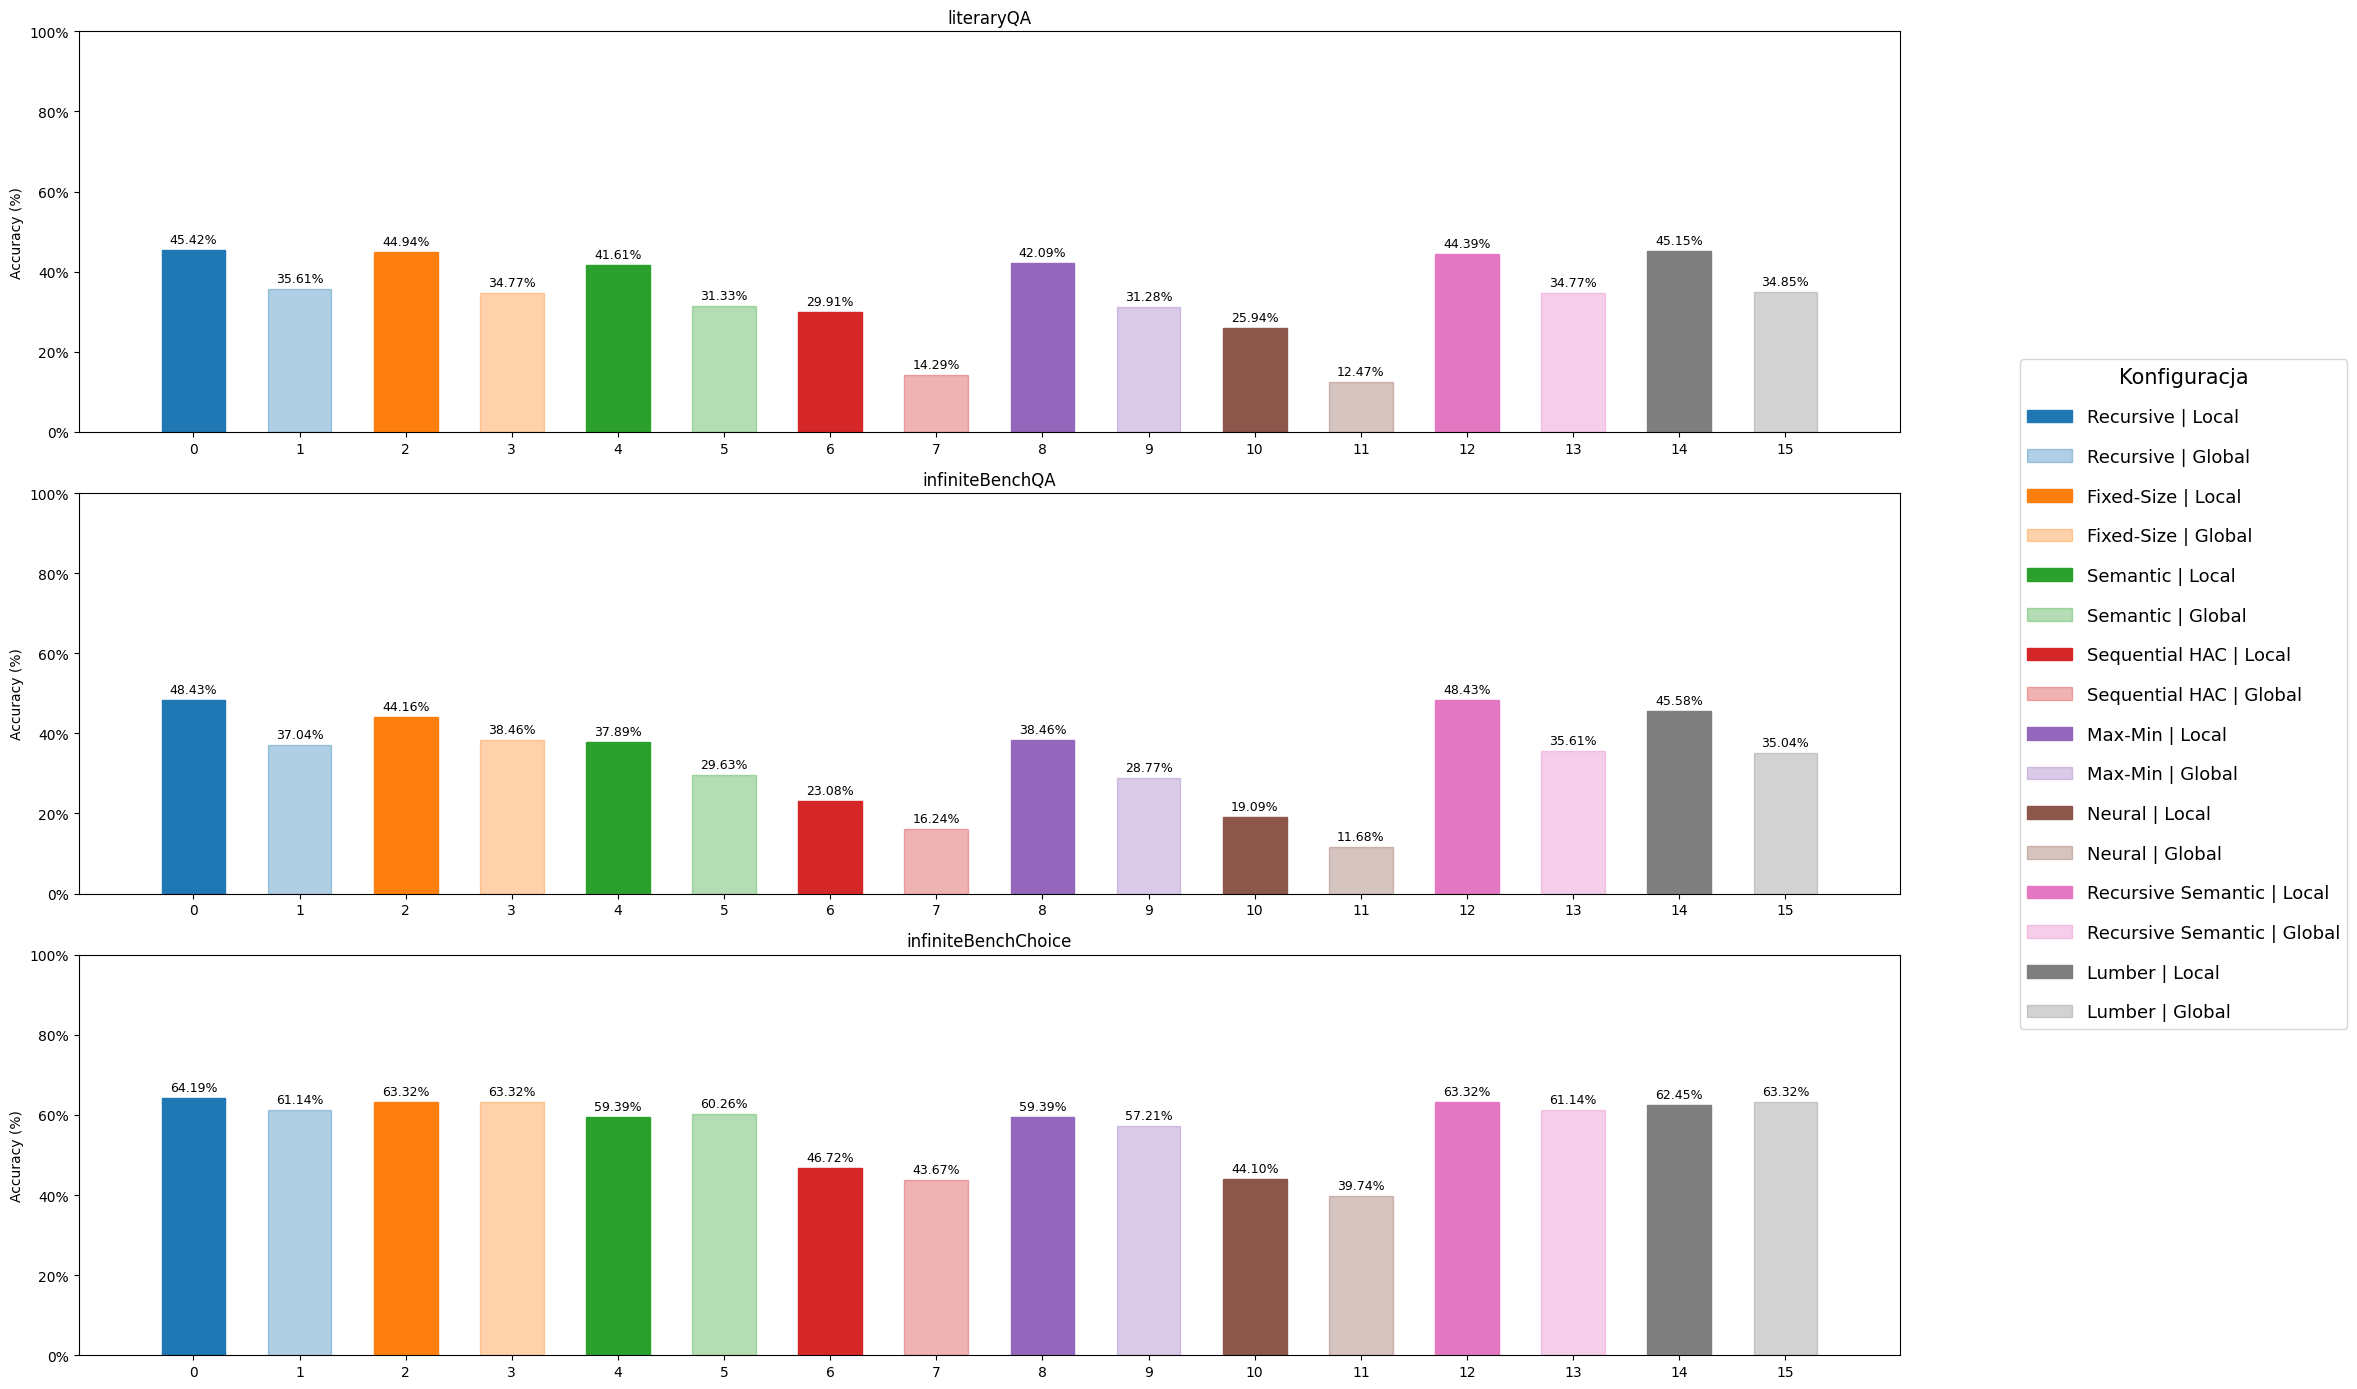

In [56]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

base_colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#7f7f7f"]

dataset_names = ["literaryQA","infiniteBenchQA","infiniteBenchChoice"]
metric_col = "answers_ratio"

method_order = ["recursive","fixed_size","chonkie_semantic","sequential_hac","max_min","neural","recursive_semantic","lumber"]

method_names = {
    "recursive":"Recursive","fixed_size":"Fixed-Size","chonkie_semantic":"Semantic",
    "sequential_hac":"Sequential HAC","max_min":"Max-Min","neural":"Neural",
    "recursive_semantic":"Recursive Semantic","lumber":"Lumber"
}

def build_label(idx):
    m = method_names.get(str(idx["chunking_name"]), str(idx["chunking_name"]))
    e = str(idx["embed_params_name"])
    return f"{m} | {'Local' if 'local' in e.lower() else 'Global'}"

def filter_df(df, name):
    x = df[df.index.get_level_values("dataset_name").str.contains(name, na=False)]
    x = x[x.index.get_level_values("rerank_params_name").str.contains("_op", na=False)]
    return x[x.index.get_level_values("generator_params_name").str.contains("4096", na=False)]

def sort_methods(df):
    order = {m:i for i,m in enumerate(method_order)}
    def key(idx):
        r = dict(zip(df.index.names, idx))
        return (
            order.get(str(r["chunking_name"]),999),
            0 if "local" in str(r["embed_params_name"]).lower() else 1
        )
    return df.loc[sorted(df.index,key=key)]

fig, axes = plt.subplots(len(dataset_names),1,figsize=(24,14))
axes = [axes] if len(dataset_names)==1 else axes

legend_handles, legend_labels = [], []
first_dataset = True

for ax, dataset_name in zip(axes,dataset_names):
    plot_df = sort_methods(filter_df(generation_result_df,dataset_name))
    print(dataset_name, plot_df.shape)

    labels = [
        build_label(dict(zip(plot_df.index.names,i)))
        for i in plot_df.index
    ]

    values = plot_df[metric_col].values / 100
    x = np.arange(len(values))

    bars = ax.bar(x,values,width=.6)

    for j,(bar,label) in enumerate(zip(bars,labels)):
        color = base_colors[(j//2)%len(base_colors)]
        alpha = 1 if "Local" in label else .35
        bar.set_color(color)
        bar.set_alpha(alpha)

        if first_dataset:
            legend_handles.append(plt.Rectangle((0,0),1,1,color=color,alpha=alpha))
            legend_labels.append(label)

    first_dataset=False

    ax.set(
        xticks=x,
        xticklabels=range(len(values)),
        ylabel="Accuracy (%)",
        title=dataset_name,
        ylim=(0,1)
    )

    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1,decimals=0))

    for bar,val in zip(bars,values):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+.01,
            f"{val*100:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(.84,.5),
    fontsize=13,
    title="Konfiguracja",
    title_fontsize=15,
    labelspacing=1.2,
    handlelength=2.5,
    markerscale=2
)

fig.tight_layout(rect=[0,0,.80,1])
plt.show()

In [57]:
generation_result_df.index

MultiIndex([('infiniteBenchChoice', 'default',   'chonkie_semantic', ...),
            ('infiniteBenchChoice', 'default',   'chonkie_semantic', ...),
            ('infiniteBenchChoice', 'default',   'chonkie_semantic', ...),
            ('infiniteBenchChoice', 'default',   'chonkie_semantic', ...),
            ('infiniteBenchChoice', 'default',   'chonkie_semantic', ...),
            ('infiniteBenchChoice', 'default',   'chonkie_semantic', ...),
            ('infiniteBenchChoice', 'default',   'chonkie_semantic', ...),
            ('infiniteBenchChoice', 'default',   'chonkie_semantic', ...),
            ('infiniteBenchChoice', 'default',         'fixed_size', ...),
            ('infiniteBenchChoice', 'default',         'fixed_size', ...),
            ...
            (         'literaryQA', 'default', 'recursive_semantic', ...),
            (         'literaryQA', 'default', 'recursive_semantic', ...),
            (         'literaryQA', 'default',     'sequential_hac', ...),
         

In [52]:
generation_result_df.index.get_level_values("rerank_name").unique()

Index(['reranker'], dtype='object', name='rerank_name')

In [53]:
print("LICZBA WSZYSTKICH:")
print(len(generation_result_df))


print("\nRERANK NAZWY:")
print(
    generation_result_df.index
    .get_level_values("rerank_name")
    .unique()
)


print("\nCHUNKING:")
print(
    generation_result_df.index
    .get_level_values("chunking_name")
    .unique()
)


print("\nEMBED PARAMS:")
print(
    generation_result_df.index
    .get_level_values("embed_params_name")
    .unique()
)

LICZBA WSZYSTKICH:
192

RERANK NAZWY:
Index(['reranker'], dtype='object', name='rerank_name')

CHUNKING:
Index(['chonkie_semantic', 'fixed_size', 'lumber', 'max_min', 'neural',
       'recursive', 'recursive_semantic', 'sequential_hac'],
      dtype='object', name='chunking_name')

EMBED PARAMS:
Index(['default_global', 'default_local'], dtype='object', name='embed_params_name')
